In [1]:
!pip install seaborn


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np 
import pandas as pd 

import matplotlib.pyplot as plt
import seaborn as sns

import os
print(os.listdir("./input"))

['urldata.csv']


In [3]:
urldata = pd.read_csv("./input/urldata.csv")

In [4]:
urldata.head()

,Unnamed: 0,url,label,result
0,0,https://www.google.com,benign,0
1,1,https://www.youtube.com,benign,0
2,2,https://www.facebook.com,benign,0
3,3,https://www.baidu.com,benign,0
4,4,https://www.wikipedia.org,benign,0


In [5]:
#Removing the unnamed columns as it is not necesary.
urldata = urldata.drop('Unnamed: 0',axis=1)

In [6]:
urldata.head()

,url,label,result
0,https://www.google.com,benign,0
1,https://www.youtube.com,benign,0
2,https://www.facebook.com,benign,0
3,https://www.baidu.com,benign,0
4,https://www.wikipedia.org,benign,0


In [7]:
urldata.shape

(450176, 3)

In [8]:
urldata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450176 entries, 0 to 450175
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   url     450176 non-null  object
 1   label   450176 non-null  object
 2   result  450176 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 10.3+ MB


In [9]:
urldata.isnull().sum()

url       0
label     0
result    0
dtype: int64

In [10]:
!pip install tld


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
#Importing dependencies
from urllib.parse import urlparse
from tld import get_tld
import os.path

In [12]:
#Length of URL
urldata['url_length'] = urldata['url'].apply(lambda i: len(str(i)))
urldata

,url,label,result,url_length
0,https://www.google.com,benign,0,22
1,https://www.youtube.com,benign,0,23
2,https://www.facebook.com,benign,0,24
3,https://www.baidu.com,benign,0,21
4,https://www.wikipedia.org,benign,0,25
...,...,...,...,...
450171,http://ecct-it.com/docmmmnn/aptgd/index.php,malicious,1,43
450172,http://faboleena.com/js/infortis/jquery/plugin...,malicious,1,159
450173,http://faboleena.com/js/infortis/jquery/plugin...,malicious,1,147
450174,http://atualizapj.com/,malicious,1,22


In [13]:
from urllib.parse import urlparse

def get_hostname_length(url):
    try:
        return len(urlparse(url).netloc)
    except:
        return 0

In [14]:
#Hostname Length
urldata['hostname_length'] = urldata['url'].apply(get_hostname_length)

In [15]:
urldata

,url,label,result,url_length,hostname_length
0,https://www.google.com,benign,0,22,14
1,https://www.youtube.com,benign,0,23,15
2,https://www.facebook.com,benign,0,24,16
3,https://www.baidu.com,benign,0,21,13
4,https://www.wikipedia.org,benign,0,25,17
...,...,...,...,...,...
450171,http://ecct-it.com/docmmmnn/aptgd/index.php,malicious,1,43,11
450172,http://faboleena.com/js/infortis/jquery/plugin...,malicious,1,159,13
450173,http://faboleena.com/js/infortis/jquery/plugin...,malicious,1,147,13
450174,http://atualizapj.com/,malicious,1,22,14


In [16]:
def get_path_length(url):
    try:
        return len(urlparse(url).path)
    except:
        return 0

In [17]:
urldata['path_length'] = urldata['url'].apply(get_path_length)


In [18]:
urldata

,url,label,result,url_length,hostname_length,path_length
0,https://www.google.com,benign,0,22,14,0
1,https://www.youtube.com,benign,0,23,15,0
2,https://www.facebook.com,benign,0,24,16,0
3,https://www.baidu.com,benign,0,21,13,0
4,https://www.wikipedia.org,benign,0,25,17,0
...,...,...,...,...,...,...
450171,http://ecct-it.com/docmmmnn/aptgd/index.php,malicious,1,43,11,25
450172,http://faboleena.com/js/infortis/jquery/plugin...,malicious,1,159,13,139
450173,http://faboleena.com/js/infortis/jquery/plugin...,malicious,1,147,13,127
450174,http://atualizapj.com/,malicious,1,22,14,1


In [19]:
urldata['hostname_length'].value_counts().head()


hostname_length
15    40696
20    39396
16    39130
14    33475
18    28995
Name: count, dtype: int64

In [20]:
re = (urldata['hostname_length'] == 0).sum()
re

np.int64(4)

In [21]:
def fd_length(url):
    try:
        path = urlparse(url).path
        parts = path.split('/')
        if len(parts) > 1:
            return len(parts[1])
        else:
            return 0
    except:
        return 0

urldata['fd_length'] = urldata['url'].apply(lambda i: fd_length(i))

In [23]:
#Length of Top Level Domain
urldata['tld'] = urldata['url'].apply(lambda i: get_tld(i,fail_silently=True))
def tld_length(tld):
    try:
        return len(tld)
    except:
        return -1

urldata['tld_length'] = urldata['tld'].apply(lambda i: tld_length(i))

In [24]:
urldata.head()


,url,label,result,url_length,hostname_length,path_length,fd_length,tld,tld_length
0,https://www.google.com,benign,0,22,14,0,0,com,3
1,https://www.youtube.com,benign,0,23,15,0,0,com,3
2,https://www.facebook.com,benign,0,24,16,0,0,com,3
3,https://www.baidu.com,benign,0,21,13,0,0,com,3
4,https://www.wikipedia.org,benign,0,25,17,0,0,org,3


In [25]:
urldata['count-'] = urldata['url'].apply(lambda i: i.count('-'))

In [26]:
urldata['count@'] = urldata['url'].apply(lambda i: i.count('@'))

In [27]:
urldata['count?'] = urldata['url'].apply(lambda i: i.count('?'))

In [28]:
urldata['count%'] = urldata['url'].apply(lambda i: i.count('%'))

In [29]:
urldata['count.'] = urldata['url'].apply(lambda i: i.count('.'))

In [30]:
urldata['count='] = urldata['url'].apply(lambda i: i.count('='))


In [31]:
urldata['count-http'] = urldata['url'].apply(lambda i : i.count('http'))


In [32]:
urldata['count-https'] = urldata['url'].apply(lambda i : i.count('https'))



In [33]:
urldata['count-www'] = urldata['url'].apply(lambda i: i.count('www'))


In [34]:
def digit_count(url):
    digits = 0
    for i in url:
        if i.isnumeric():
            digits = digits + 1
    return digits
urldata['count-digits']= urldata['url'].apply(lambda i: digit_count(i))

In [35]:
def letter_count(url):
    letters = 0
    for i in url:
        if i.isalpha():
            letters = letters + 1
    return letters
urldata['count-letters']= urldata['url'].apply(lambda i: letter_count(i))

In [36]:
def no_of_dir(url):
    try:
        path = urlparse(url).path
        return path.count('/')
    except:
        return 0
urldata['count_dir'] = urldata['url'].apply(lambda i: no_of_dir(i))

In [37]:
urldata.head()


,url,label,result,url_length,hostname_length,path_length,fd_length,tld,tld_length,count-,...,count?,count%,count.,count=,count-http,count-https,count-www,count-digits,count-letters,count_dir
0,https://www.google.com,benign,0,22,14,0,0,com,3,0,...,0,0,2,0,1,1,1,0,17,0
1,https://www.youtube.com,benign,0,23,15,0,0,com,3,0,...,0,0,2,0,1,1,1,0,18,0
2,https://www.facebook.com,benign,0,24,16,0,0,com,3,0,...,0,0,2,0,1,1,1,0,19,0
3,https://www.baidu.com,benign,0,21,13,0,0,com,3,0,...,0,0,2,0,1,1,1,0,16,0
4,https://www.wikipedia.org,benign,0,25,17,0,0,org,3,0,...,0,0,2,0,1,1,1,0,20,0


<h2>Binary Features<h1>

In [38]:
import re

In [39]:
#Use of IP or not in domain
def having_ip_address(url):
    match = re.search(
        '(([01]?\\d\\d?|2[0-4]\\d|25[0-5])\\.([01]?\\d\\d?|2[0-4]\\d|25[0-5])\\.([01]?\\d\\d?|2[0-4]\\d|25[0-5])\\.'
        '([01]?\\d\\d?|2[0-4]\\d|25[0-5])\\/)|'  # IPv4
        '((0x[0-9a-fA-F]{1,2})\\.(0x[0-9a-fA-F]{1,2})\\.(0x[0-9a-fA-F]{1,2})\\.(0x[0-9a-fA-F]{1,2})\\/)' # IPv4 in hexadecimal
        '(?:[a-fA-F0-9]{1,4}:){7}[a-fA-F0-9]{1,4}', url)  # Ipv6
    if match:
        # print match.group()
        return -1
    else:
        # print 'No matching pattern found'
        return 1
urldata['use_of_ip'] = urldata['url'].apply(lambda i: having_ip_address(i))

In [40]:
def shortening_service(url):
    match = re.search('bit\.ly|goo\.gl|shorte\.st|go2l\.ink|x\.co|ow\.ly|t\.co|tinyurl|tr\.im|is\.gd|cli\.gs|'
                      'yfrog\.com|migre\.me|ff\.im|tiny\.cc|url4\.eu|twit\.ac|su\.pr|twurl\.nl|snipurl\.com|'
                      'short\.to|BudURL\.com|ping\.fm|post\.ly|Just\.as|bkite\.com|snipr\.com|fic\.kr|loopt\.us|'
                      'doiop\.com|short\.ie|kl\.am|wp\.me|rubyurl\.com|om\.ly|to\.ly|bit\.do|t\.co|lnkd\.in|'
                      'db\.tt|qr\.ae|adf\.ly|goo\.gl|bitly\.com|cur\.lv|tinyurl\.com|ow\.ly|bit\.ly|ity\.im|'
                      'q\.gs|is\.gd|po\.st|bc\.vc|twitthis\.com|u\.to|j\.mp|buzurl\.com|cutt\.us|u\.bb|yourls\.org|'
                      'x\.co|prettylinkpro\.com|scrnch\.me|filoops\.info|vzturl\.com|qr\.net|1url\.com|tweez\.me|v\.gd|'
                      'tr\.im|link\.zip\.net',
                      url)
    if match:
        return -1
    else:
        return 1
urldata['short_url'] = urldata['url'].apply(lambda i: shortening_service(i))

<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:3: SyntaxWarning: invalid escape sequence '\.'
<>:4: SyntaxWarning: invalid escape sequence '\.'
<>:5: SyntaxWarning: invalid escape sequence '\.'
<>:6: SyntaxWarning: invalid escape sequence '\.'
<>:7: SyntaxWarning: invalid escape sequence '\.'
<>:8: SyntaxWarning: invalid escape sequence '\.'
<>:9: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:3: SyntaxWarning: invalid escape sequence '\.'
<>:4: SyntaxWarning: invalid escape sequence '\.'
<>:5: SyntaxWarning: invalid escape sequence '\.'
<>:6: SyntaxWarning: invalid escape sequence '\.'
<>:7: SyntaxWarning: invalid escape sequence '\.'
<>:8: SyntaxWarning: invalid escape sequence '\.'
<>:9: SyntaxWarning: invalid escape sequence '\.'
C:\Users\Usuario\AppData\Local\Temp\ipykernel_28004\1550753800.py:2: SyntaxWarning: invalid escape sequence '\.'
  match = re.search('bit\.ly|goo\.gl|shorte\.st|go2l\.ink|x\.co|ow\.ly|t\.co|tinyurl|tr

In [41]:
urldata.head()

,url,label,result,url_length,hostname_length,path_length,fd_length,tld,tld_length,count-,...,count.,count=,count-http,count-https,count-www,count-digits,count-letters,count_dir,use_of_ip,short_url
0,https://www.google.com,benign,0,22,14,0,0,com,3,0,...,2,0,1,1,1,0,17,0,1,1
1,https://www.youtube.com,benign,0,23,15,0,0,com,3,0,...,2,0,1,1,1,0,18,0,1,1
2,https://www.facebook.com,benign,0,24,16,0,0,com,3,0,...,2,0,1,1,1,0,19,0,1,1
3,https://www.baidu.com,benign,0,21,13,0,0,com,3,0,...,2,0,1,1,1,0,16,0,1,1
4,https://www.wikipedia.org,benign,0,25,17,0,0,org,3,0,...,2,0,1,1,1,0,20,0,1,1


<Axes: >

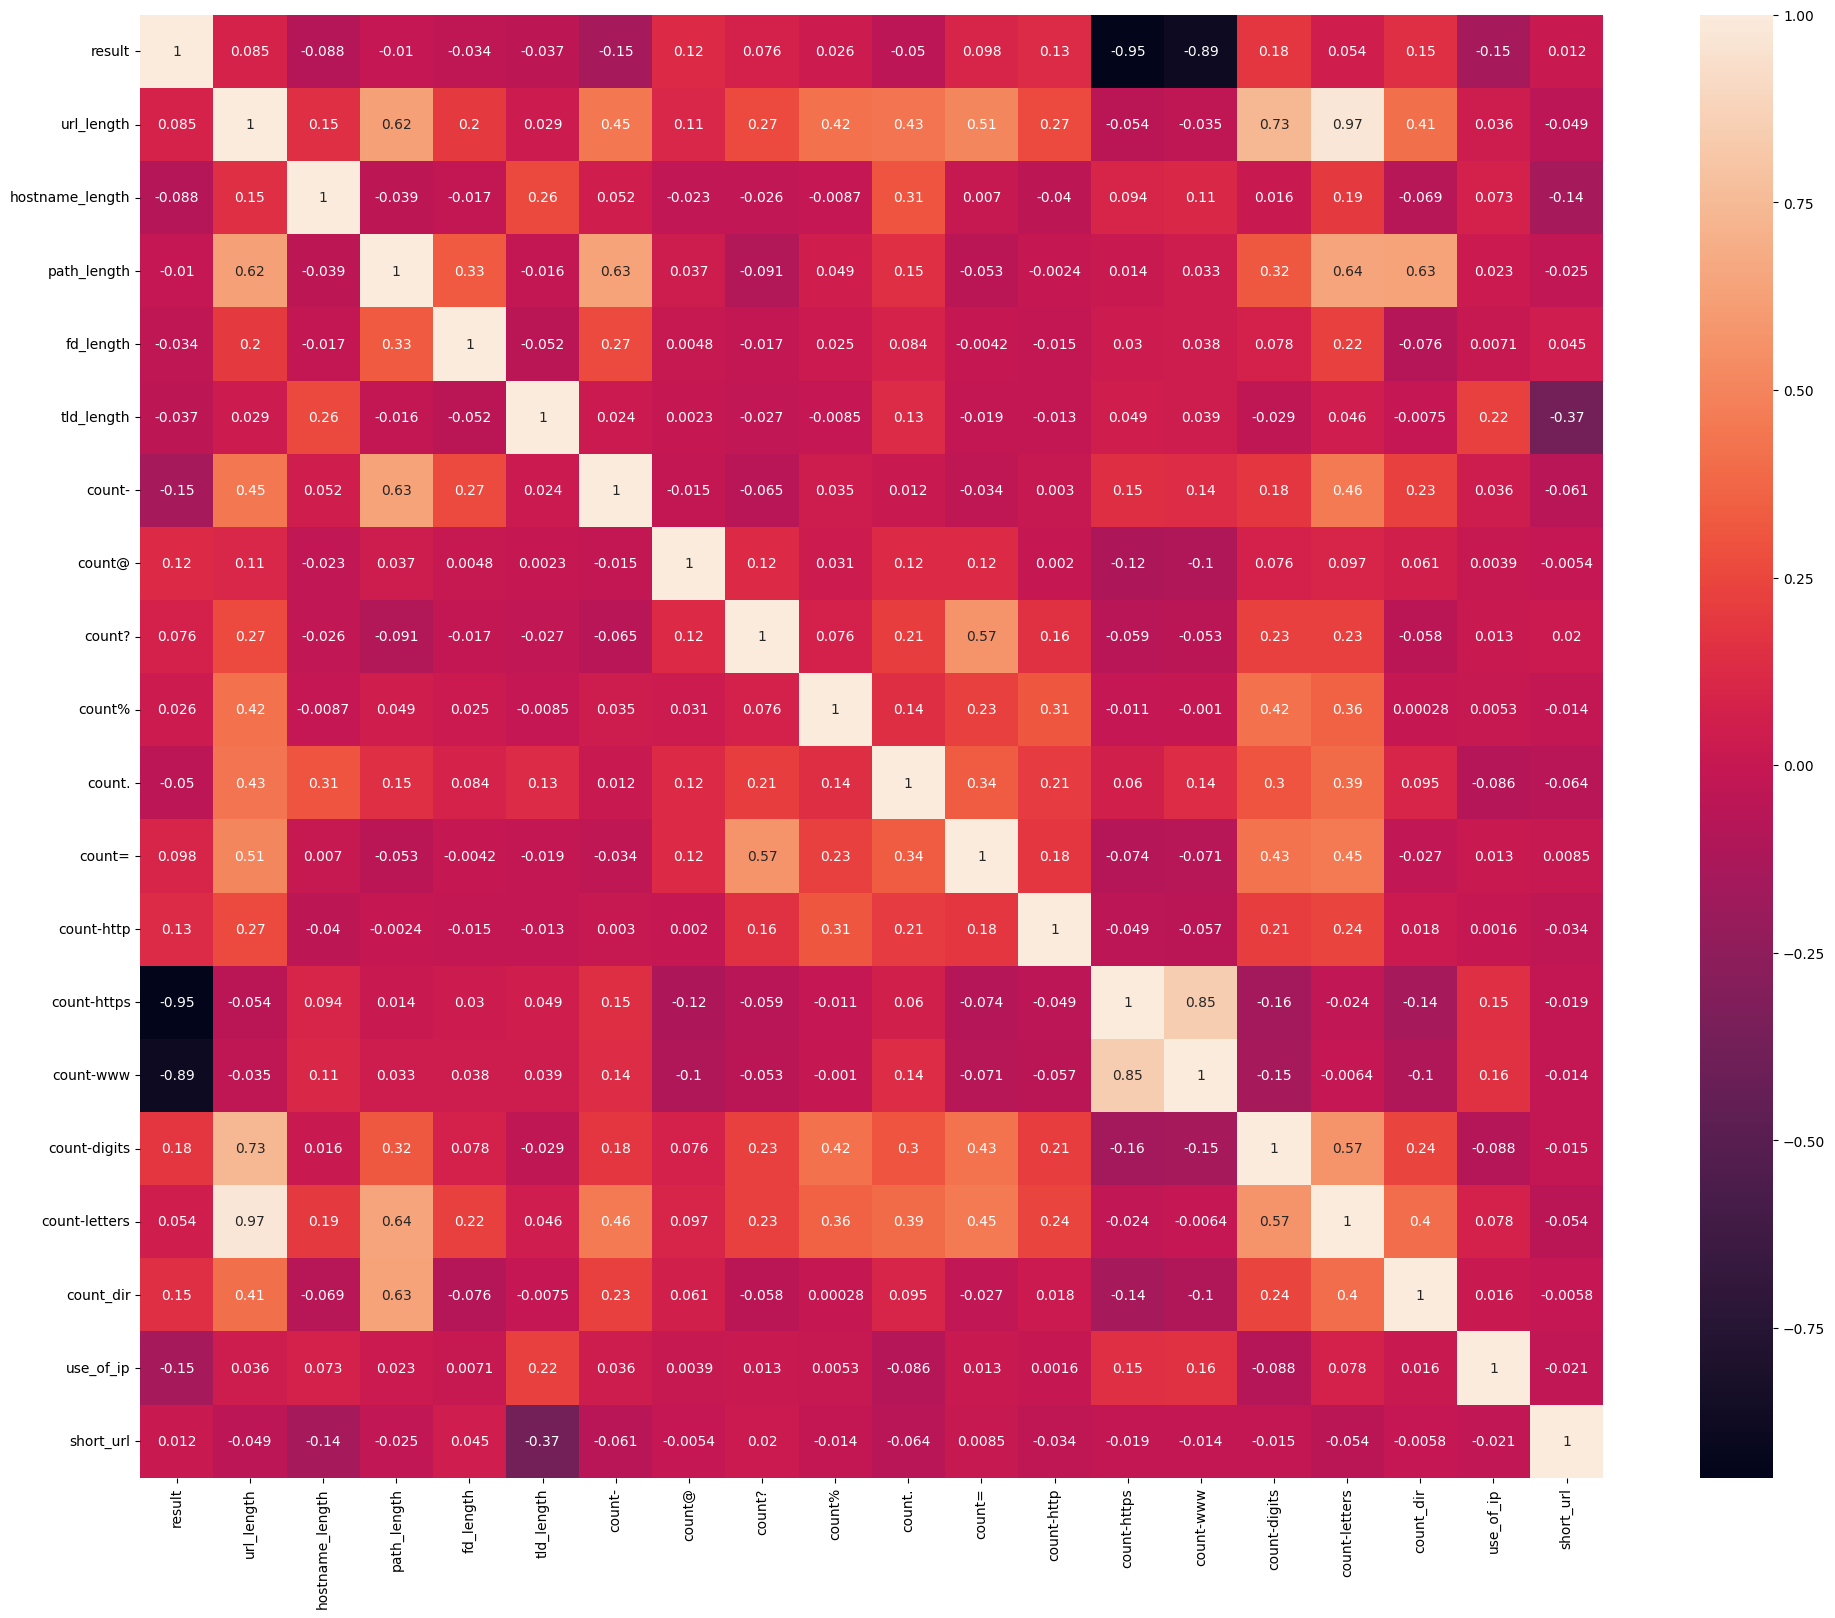

In [42]:
#Heatmap
numeric_df = urldata.select_dtypes(include=['number'])

corrmat = numeric_df.corr()

plt.figure(figsize=(25,19))
sns.heatmap(corrmat, square=True, annot=True, annot_kws={'size':10})


Text(0, 0.5, 'Number Of URLs')

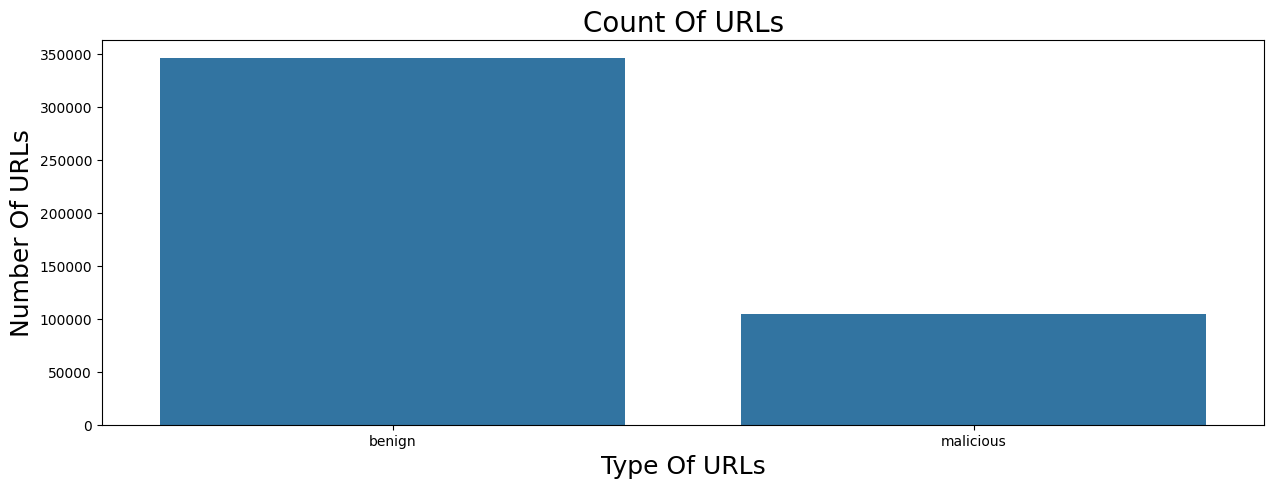

In [43]:
plt.figure(figsize=(15,5))
sns.countplot(x='label',data=urldata)
plt.title("Count Of URLs",fontsize=20)
plt.xlabel("Type Of URLs",fontsize=18)
plt.ylabel("Number Of URLs",fontsize=18)

In [44]:
print("Percent Of Malicious URLs:{:.2f} %".format(len(urldata[urldata['label']=='malicious'])/len(urldata['label'])*100))
print("Percent Of Benign URLs:{:.2f} %".format(len(urldata[urldata['label']=='benign'])/len(urldata['label'])*100))

Percent Of Malicious URLs:23.20 %
Percent Of Benign URLs:76.80 %


(0.0, 1000.0)

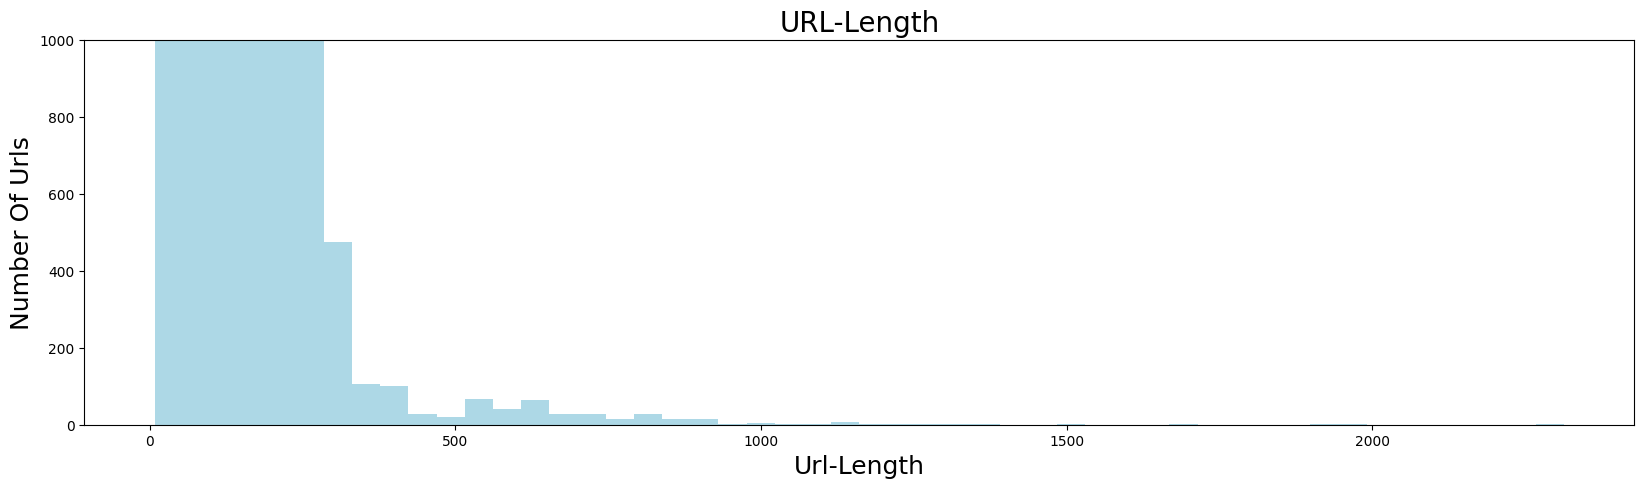

In [45]:
plt.figure(figsize=(20,5))
plt.hist(urldata['url_length'],bins=50,color='LightBlue')
plt.title("URL-Length",fontsize=20)
plt.xlabel("Url-Length",fontsize=18)
plt.ylabel("Number Of Urls",fontsize=18)
plt.ylim(0,1000)

(0.0, 1000.0)

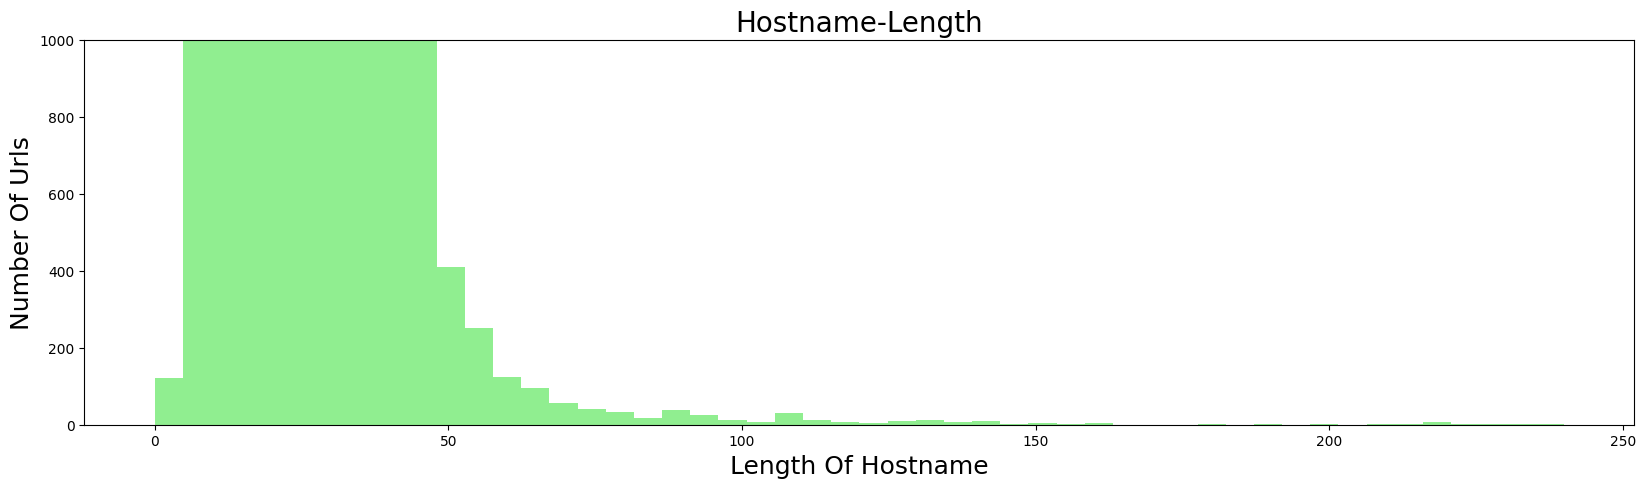

In [46]:
plt.figure(figsize=(20,5))
plt.hist(urldata['hostname_length'],bins=50,color='Lightgreen')
plt.title("Hostname-Length",fontsize=20)
plt.xlabel("Length Of Hostname",fontsize=18)
plt.ylabel("Number Of Urls",fontsize=18)
plt.ylim(0,1000)

(0.0, 1000.0)

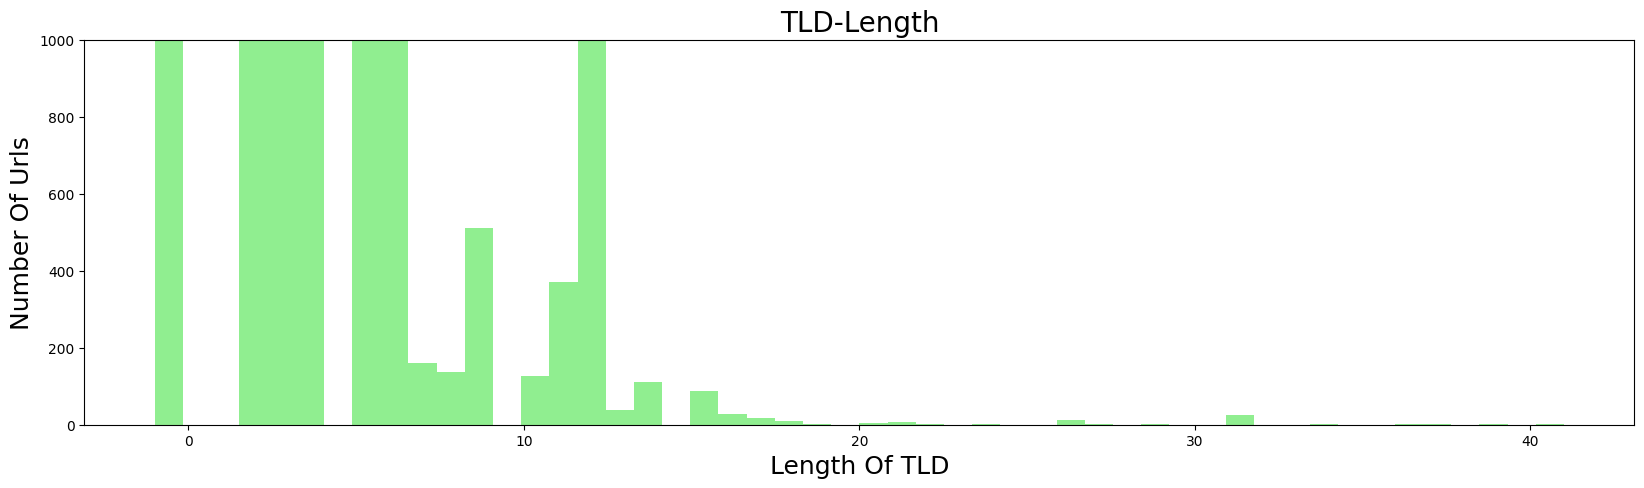

In [47]:
plt.figure(figsize=(20,5))
plt.hist(urldata['tld_length'],bins=50,color='Lightgreen')
plt.title("TLD-Length",fontsize=20)
plt.xlabel("Length Of TLD",fontsize=18)
plt.ylabel("Number Of Urls",fontsize=18)
plt.ylim(0,1000)

Text(0, 0.5, 'Number Of URLs')

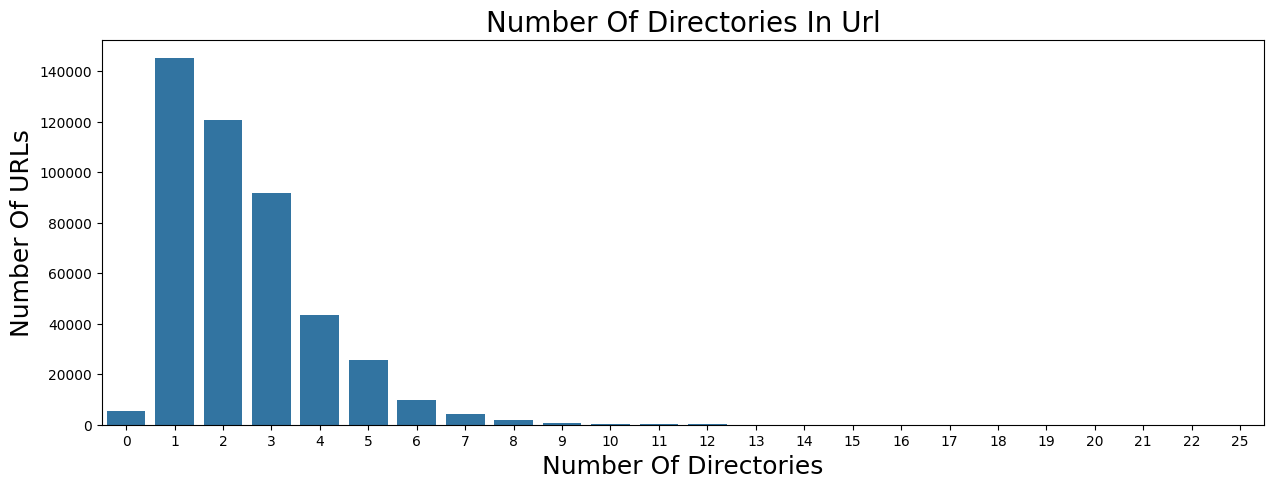

In [48]:
plt.figure(figsize=(15,5))
plt.title("Number Of Directories In Url",fontsize=20)
sns.countplot(x='count_dir',data=urldata)
plt.xlabel("Number Of Directories",fontsize=18)
plt.ylabel("Number Of URLs",fontsize=18)

Text(0, 0.5, 'Number Of URLs')

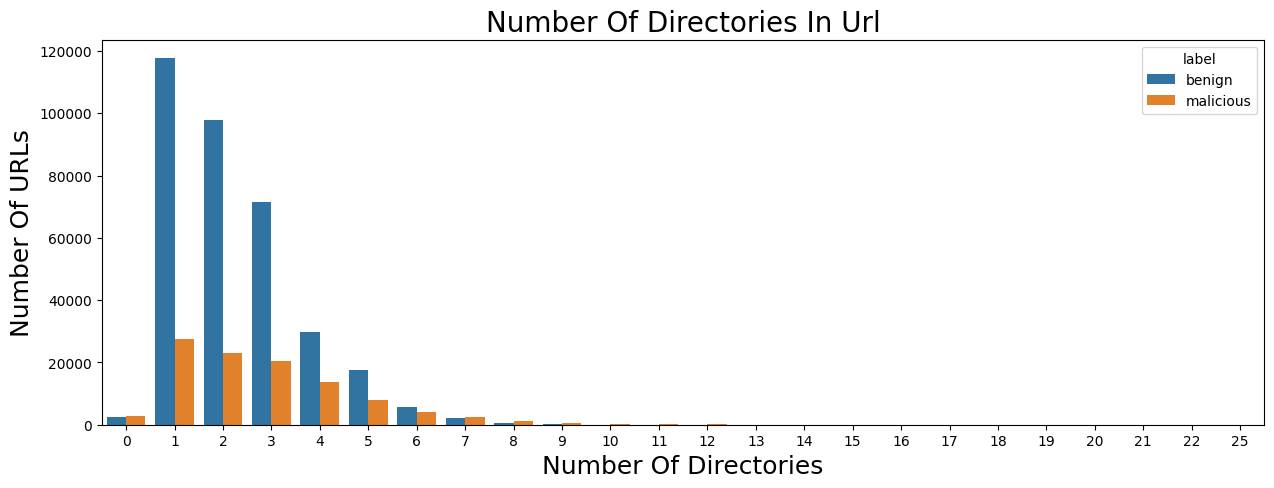

In [49]:
plt.figure(figsize=(15,5))
plt.title("Number Of Directories In Url",fontsize=20)
sns.countplot(x='count_dir',data=urldata,hue='label')
plt.xlabel("Number Of Directories",fontsize=18)
plt.ylabel("Number Of URLs",fontsize=18)

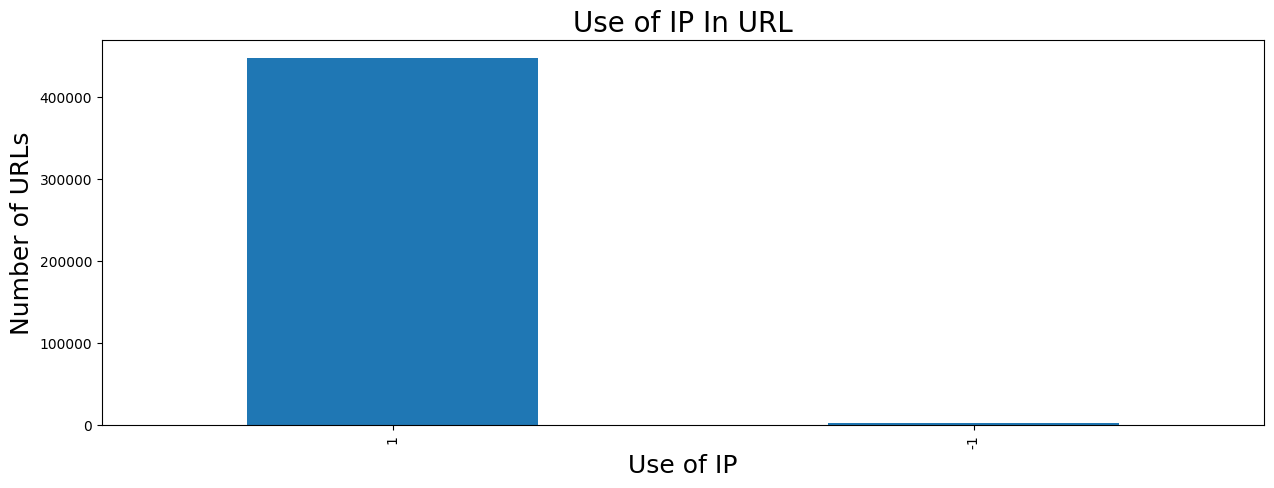

In [50]:
plt.figure(figsize=(15,5))
urldata['use_of_ip'].value_counts().plot(kind='bar')
plt.title("Use of IP In URL", fontsize=20)
plt.xlabel("Use of IP", fontsize=18)
plt.ylabel("Number of URLs", fontsize=18)
plt.show()


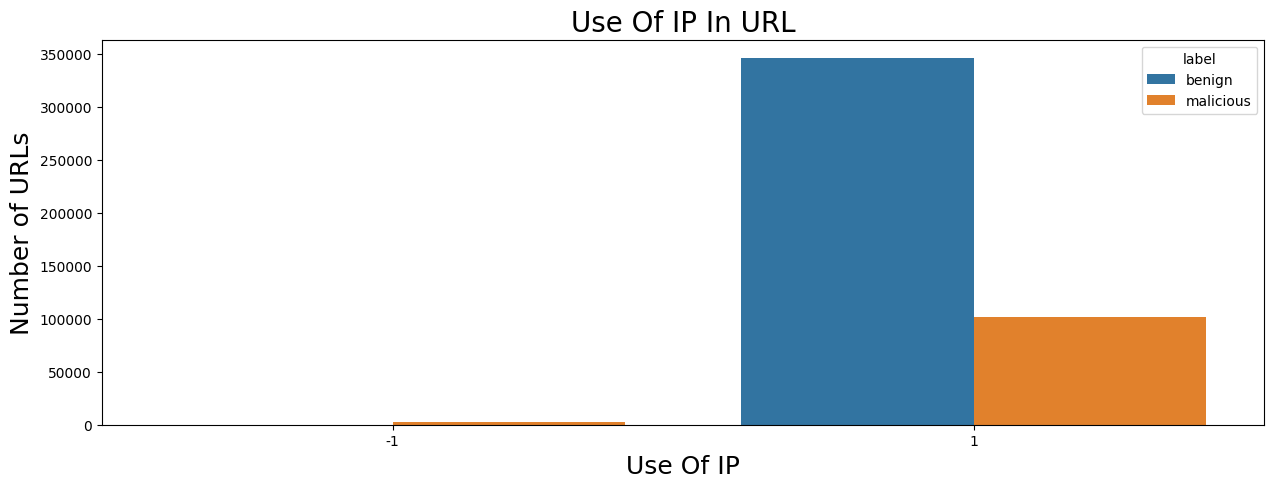

In [52]:
plt.figure(figsize=(15,5))
sns.countplot(data=urldata, x='use_of_ip', hue='label')
plt.title("Use Of IP In URL", fontsize=20)
plt.xlabel("Use Of IP", fontsize=18)
plt.ylabel("Number of URLs", fontsize=18)
plt.show()



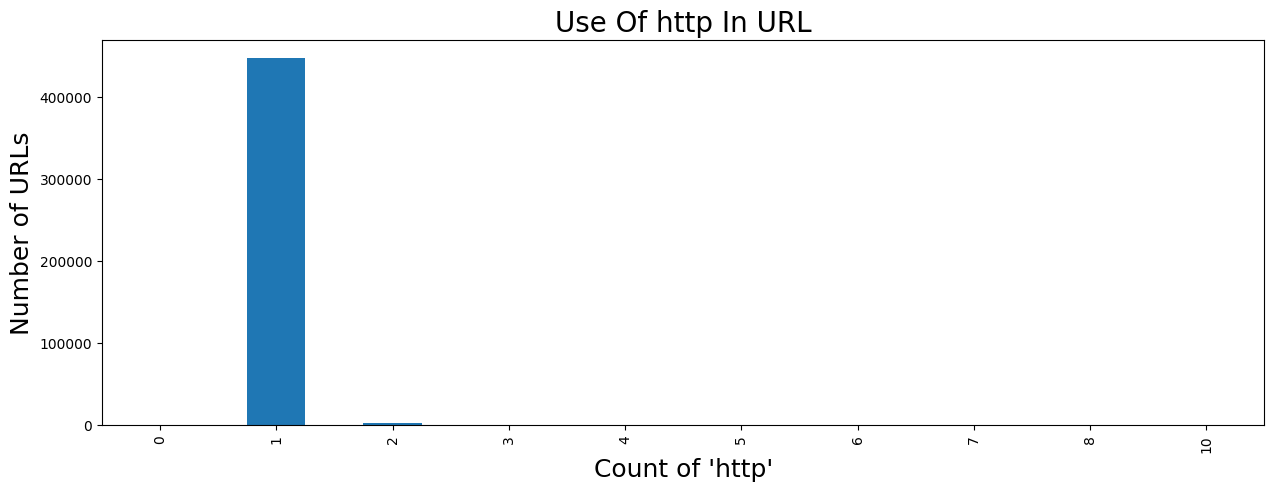

In [53]:
plt.figure(figsize=(15,5))
urldata['count-http'].value_counts().sort_index().plot(kind='bar')
plt.title("Use Of http In URL", fontsize=20)
plt.xlabel("Count of 'http'", fontsize=18)
plt.ylabel("Number of URLs", fontsize=18)
plt.show()


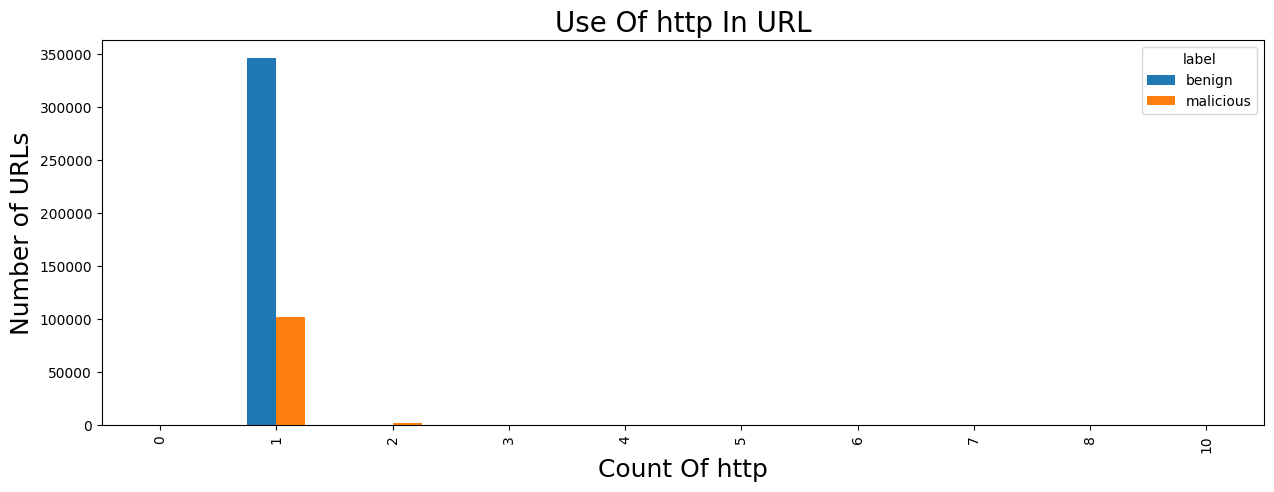

In [54]:
ct = urldata.groupby(['count-http', 'label']).size().unstack()

ct.plot(kind='bar', figsize=(15,5))
plt.title("Use Of http In URL", fontsize=20)
plt.xlabel("Count Of http", fontsize=18)
plt.ylabel("Number of URLs", fontsize=18)
plt.show()


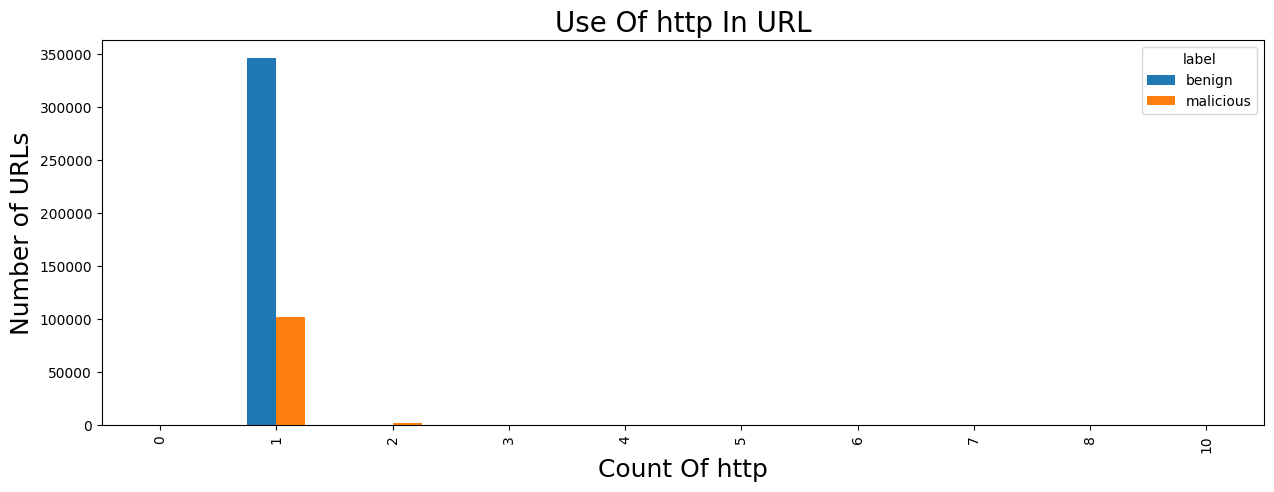

In [55]:
ct = urldata.groupby(['count-http', 'label']).size().unstack(fill_value=0)

ct.plot(kind='bar', figsize=(15,5))
plt.title("Use Of http In URL", fontsize=20)
plt.xlabel("Count Of http", fontsize=18)
plt.ylabel("Number of URLs", fontsize=18)
plt.show()


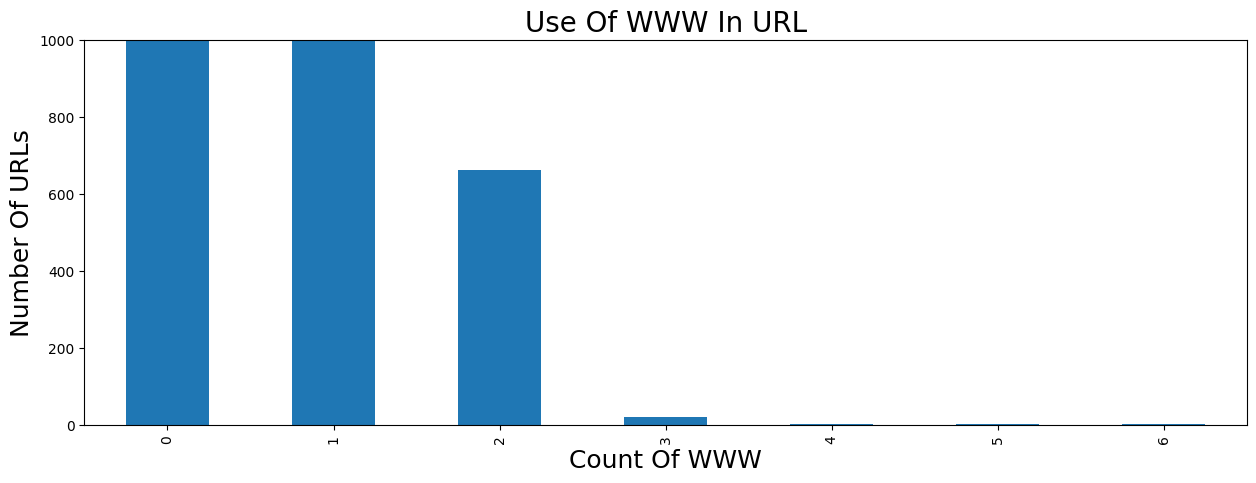

In [56]:
plt.figure(figsize=(15,5))
urldata['count-www'].value_counts().sort_index().plot(kind='bar')
plt.title("Use Of WWW In URL", fontsize=20)
plt.xlabel("Count Of WWW", fontsize=18)
plt.ylabel("Number Of URLs", fontsize=18)
plt.ylim(0, 1000)
plt.show()


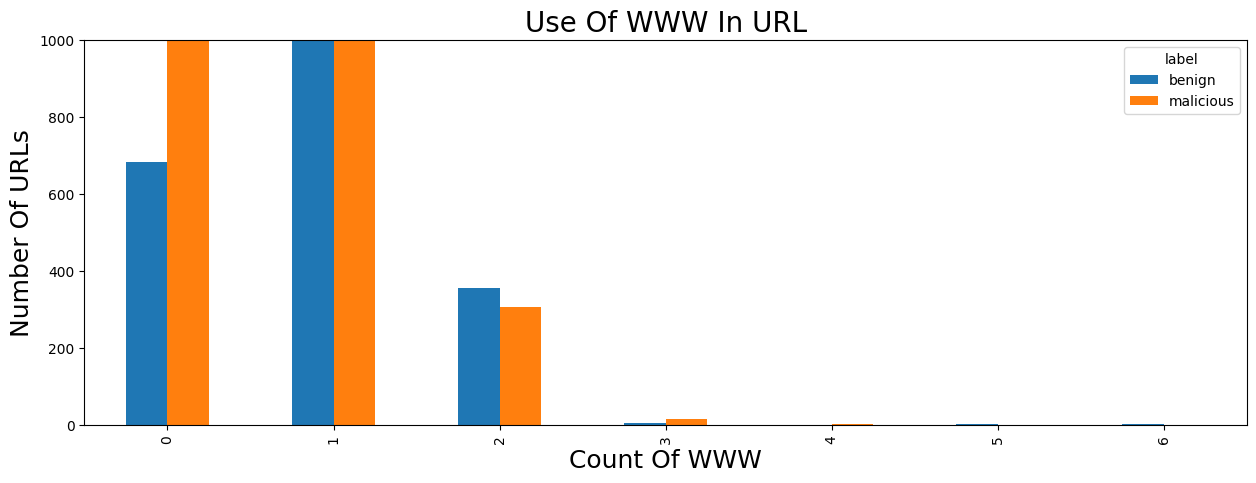

In [57]:
ct = urldata.groupby(['count-www', 'label']).size().unstack(fill_value=0)

ct.plot(kind='bar', figsize=(15,5))
plt.title("Use Of WWW In URL", fontsize=20)
plt.xlabel("Count Of WWW", fontsize=18)
plt.ylabel("Number Of URLs", fontsize=18)
plt.ylim(0, 1000)
plt.show()


<h2>Building Models Using Lexical Features Only</h2>

In [70]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

from sklearn.metrics import confusion_matrix,classification_report,accuracy_score

from sklearn.tree import DecisionTreeClassifier

from sklearn.linear_model import LogisticRegression

In [71]:
#Predictor Variables
x = urldata[['hostname_length',
       'path_length', 'fd_length', 'tld_length', 'count-', 'count@', 'count?',
       'count%', 'count.', 'count=', 'count-http','count-https', 'count-www', 'count-digits',
       'count-letters', 'count_dir', 'use_of_ip']]

#Target Variable
y = urldata['result']

In [72]:
x.shape

(450176, 17)

In [73]:
y.shape


(450176,)

In [74]:
#Splitting the data into Training and Testing
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.3, random_state=42)

<h2>Decision Tree</h2>

In [75]:
#Decision Tree
dt_model = DecisionTreeClassifier()
dt_model.fit(x_train,y_train)

dt_predictions = dt_model.predict(x_test)
accuracy_score(y_test,dt_predictions)

0.9954621038067555

In [76]:
print(confusion_matrix(y_test,dt_predictions))


[[241247    705]
 [   725  72447]]


<h2>Random Forest</h2>

In [77]:
#Random Forest
rfc = RandomForestClassifier()
rfc.fit(x_train, y_train)

rfc_predictions = rfc.predict(x_test)
accuracy_score(y_test, rfc_predictions)

0.9972645688681281

In [83]:
print(confusion_matrix(y_test,rfc_predictions))

[[241669    283]
 [   579  72593]]


<h2>Logistic Regression</h2>

In [87]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

log_model.fit(x_train_scaled, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [88]:
log_predictions = log_model.predict(x_test_scaled)


In [89]:
accuracy_score(y_test, log_predictions)


0.9964299767710488

In [ ]:
print(confusion_matrix(y_test, log_predictions))

[[241413    539]
 [   586  72586]]


<h2>MPL Classifier</h2>

In [95]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

In [96]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [97]:
mlp = MLPClassifier(
    hidden_layer_sizes=(50, 50),
    max_iter=200,
    random_state=42
)

mlp.fit(x_train_scaled, y_train)

,hidden_layer_sizes,"(50, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,200
,shuffle,True
,random_state,42


In [98]:
mlp_predictions = mlp.predict(x_test_scaled)

accuracy_score(y_test, mlp_predictions)
print(confusion_matrix(y_test, mlp_predictions))


[[241697    255]
 [   638  72534]]


In [99]:
import joblib

In [100]:
joblib.dump(mlp, 'mlp_url_model.pkl')
joblib.dump(scaler, 'mlp_scaler.pkl')

['mlp_scaler.pkl']